# Imports and setup

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid", palette="tab20c")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_plot(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", bbox_inches="tight", dpi=300)

# Data loading

In [3]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

df = train_df.copy()
df.columns = df.columns.str.strip()

df.head()
df.columns

Train shape: (45593, 20)
Test shape: (11399, 19)


Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='str')

# Column renaming

In [4]:
df.rename(columns={
    "ID": "order_id",
    "Delivery_person_ID": "driver_id",
    "Delivery_person_Age": "driver_age",
    "Delivery_person_Ratings": "driver_rating",
    "Restaurant_latitude": "restaurant_latitude",
    "Restaurant_longitude": "restaurant_longitude",
    "Delivery_location_latitude": "delivery_latitude",
    "Delivery_location_longitude": "delivery_longitude",
    "Order_Date": "order_date",
    "Time_Orderd": "order_time",
    "Time_Order_picked": "pickup_time",
    "Weatherconditions": "weather",
    "Road_traffic_density": "traffic_density",
    "Vehicle_condition": "vehicle_condition",
    "Type_of_order": "order_type",
    "Type_of_vehicle": "vehicle_type",
    "multiple_deliveries": "num_deliveries",
    "Festival": "is_festival",
    "City": "city",
    "Time_taken(min)": "delivery_time_min"
}, inplace=True)

### Feature Descriptions

- **order_id**: Unique identifier for each order  
- **driver_id**: Unique identifier for each delivery driver  

- **driver_age**: Age of the delivery driver  
- **driver_rating**: Rating of the delivery driver based on past performance  

- **vehicle_condition**: Condition of the delivery vehicle (higher = better condition)  
- **vehicle_type**: Type of vehicle used for delivery (e.g., bike, scooter)  

- **order_type**: Type/category of the order (e.g., food, grocery)  
- **num_deliveries**: Number of deliveries assigned to the driver at the time  

- **is_festival**: Indicates whether the order was placed during a festival (Yes/No)  
- **city**: City where the delivery takes place  

- **weather**: Weather conditions during delivery (e.g., Sunny, Rainy)  
- **traffic_density**: Traffic level during delivery (e.g., Low, Medium, High)  

- **restaurant_latitude**: Latitude of the restaurant location  
- **restaurant_longitude**: Longitude of the restaurant location  
- **delivery_latitude**: Latitude of the delivery destination  
- **delivery_longitude**: Longitude of the delivery destination  

- **order_date**: Date when the order was placed  
- **order_time**: Time when the order was placed  
- **pickup_time**: Time when the order was picked up by the driver  

- **distance_km**: Distance between restaurant and delivery location (in kilometers)  

- **delivery_time_min**: Total delivery time in minutes (target variable)

# Dataset structure into 3 logical tables

In [5]:
orders_df = df[[
    "order_id", "driver_id", "order_date",
    "order_time", "pickup_time",
    "order_type", "num_deliveries",
    "is_festival", "city", "delivery_time_min"
]].copy()

delivery_partners_df = df[[
    "driver_id", "driver_age",
    "driver_rating", "vehicle_condition",
    "vehicle_type"
]].drop_duplicates().reset_index(drop=True)

location_env_df = df[[
    "order_id", "restaurant_latitude", "restaurant_longitude",
    "delivery_latitude", "delivery_longitude",
    "weather", "traffic_density"
]].copy()

# Save those 3 files

In [6]:
orders_df.to_csv("../data/raw/orders.csv", index=False)
delivery_partners_df.to_csv("../data/raw/delivery_partners.csv", index=False)
location_env_df.to_csv("../data/raw/location_env.csv", index=False)

# Data quality assessment before cleaning

In [8]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (45593, 20)
<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              45593 non-null  str    
 1   driver_id             45593 non-null  str    
 2   driver_age            45593 non-null  str    
 3   driver_rating         45593 non-null  str    
 4   restaurant_latitude   45593 non-null  float64
 5   restaurant_longitude  45593 non-null  float64
 6   delivery_latitude     45593 non-null  float64
 7   delivery_longitude    45593 non-null  float64
 8   order_date            45593 non-null  str    
 9   order_time            45593 non-null  str    
 10  pickup_time           45593 non-null  str    
 11  weather               45593 non-null  str    
 12  traffic_density       45593 non-null  str    
 13  vehicle_condition     45593 non-null  int64  
 14  order_type            45593 non-null  str    
 15  veh

In [9]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
order_id                0
driver_id               0
driver_age              0
driver_rating           0
restaurant_latitude     0
restaurant_longitude    0
delivery_latitude       0
delivery_longitude      0
order_date              0
order_time              0
pickup_time             0
weather                 0
traffic_density         0
vehicle_condition       0
order_type              0
vehicle_type            0
num_deliveries          0
is_festival             0
city                    0
delivery_time_min       0
dtype: int64


In [21]:
print("\nData types:")
print(df.dtypes)


Data types:
order_id                    str
driver_id                   str
driver_age                  str
driver_rating               str
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date                  str
order_time                  str
pickup_time                 str
weather                     str
traffic_density             str
vehicle_condition         int64
order_type                  str
vehicle_type                str
num_deliveries              str
is_festival                 str
city                        str
delivery_time_min           str
dtype: object


# UNIQUE VALUES INSPECTION (TEXT CHECK)

In [22]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print("Unique values (sample):")
    print(df[col].unique()[:20])


===== order_id =====
Unique values (sample):
<StringArray>
['0x4607 ', '0xb379 ', '0x5d6d ', '0x7a6a ', '0x70a2 ', '0x9bb4 ', '0x95b4 ',
 '0x9eb2 ', '0x1102 ', '0xcdcd ', '0xd987 ', '0x2784 ', '0xc8b6 ', '0xdb64 ',
 '0x3af3 ', '0x3aab ', '0x689b ', '0x6f67 ', '0xc9cf ', '0x36b8 ']
Length: 20, dtype: str

===== driver_id =====
Unique values (sample):
<StringArray>
[  'INDORES13DEL02 ',   'BANGRES18DEL02 ',   'BANGRES19DEL01 ',
  'COIMBRES13DEL02 ',   'CHENRES12DEL01 ',    'HYDRES09DEL03 ',
 'RANCHIRES15DEL01 ',    'MYSRES15DEL02 ',    'HYDRES05DEL02 ',
    'DEHRES17DEL01 ',    'KOCRES16DEL01 ',   'PUNERES13DEL03 ',
   'LUDHRES15DEL02 ',    'KNPRES14DEL02 ',    'MUMRES15DEL03 ',
    'MYSRES01DEL01 ',   'PUNERES20DEL01 ',    'HYDRES14DEL01 ',
    'KOLRES15DEL03 ',   'PUNERES19DEL02 ']
Length: 20, dtype: str

===== driver_age =====
Unique values (sample):
<StringArray>
[  '37',   '34',   '23',   '38',   '32',   '22',   '33',   '35',   '36',
   '21',   '24',   '29',   '25',   '31',   '27',

C:\Users\lynny\AppData\Local\Temp\ipykernel_16092\1606259683.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [23]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False).head(10))


===== order_id =====
order_id
0x4607     1
0xb379     1
0x5d6d     1
0x7a6a     1
0x70a2     1
0x9bb4     1
0x95b4     1
0x9eb2     1
0x1102     1
0xcdcd     1
Name: count, dtype: int64

===== driver_id =====
driver_id
JAPRES11DEL02        67
PUNERES01DEL01       67
RANCHIRES02DEL01     66
VADRES11DEL02        66
JAPRES03DEL01        66
HYDRES04DEL02        66
VADRES08DEL02        66
SURRES11DEL01        65
INDORES08DEL02       65
VADRES11DEL01        65
Name: count, dtype: int64

===== driver_age =====
driver_age
35    2262
36    2260
37    2227
30    2226
38    2219
24    2210
32    2202
22    2196
29    2191
33    2187
Name: count, dtype: int64

===== driver_rating =====
driver_rating
4.8     7148
4.7     7142
4.9     7041
4.6     6940
5       3996
4.5     3303
NaN     1908
4.1     1430
4.2     1418
4.3     1409
Name: count, dtype: int64

===== order_date =====
order_date
15-03-2022    1192
03-04-2022    1178
13-03-2022    1169
26-03-2022    1166
24-03-2022    1162
09-03-2022    11

# TARGET / IMPORTANT COLUMN INSPECTION

In [24]:
print(df["delivery_time_min"].head(10))
print("Max rating:", df["driver_rating"].max())
print("Unique ratings sample:", df["driver_rating"].unique()[:30])

0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
5    (min) 26
6    (min) 40
7    (min) 32
8    (min) 34
9    (min) 46
Name: delivery_time_min, dtype: str
Max rating: NaN 
Unique ratings sample: <StringArray>
[ '4.9',  '4.5',  '4.4',  '4.7',  '4.6',  '4.8',  '4.2',  '4.3',    '4',
  '4.1',    '5',  '3.5', 'NaN ',  '3.8',  '3.9',  '3.7',  '2.6',  '2.5',
  '3.6',  '3.1',  '2.7',    '1',  '3.2',  '3.3',    '6',  '3.4',  '2.8',
  '2.9',    '3']
Length: 29, dtype: str


In [25]:
for col in ["weather", "traffic_density", "is_festival"]:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

print(df.dtypes)


weather:
weather
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
Name: count, dtype: int64

traffic_density:
traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
NaN          601
Name: count, dtype: int64

is_festival:
is_festival
No      44469
Yes       896
NaN       228
Name: count, dtype: int64
order_id                    str
driver_id                   str
driver_age                  str
driver_rating               str
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date                  str
order_time                  str
pickup_time                 str
weather                     str
traffic_density             str
vehicle_condition         int64
order_type                  str
vehicle_type                str
num_deliveries              str
is_festival            

# Univariate Analysis
# Target variable visuals
## Distribution

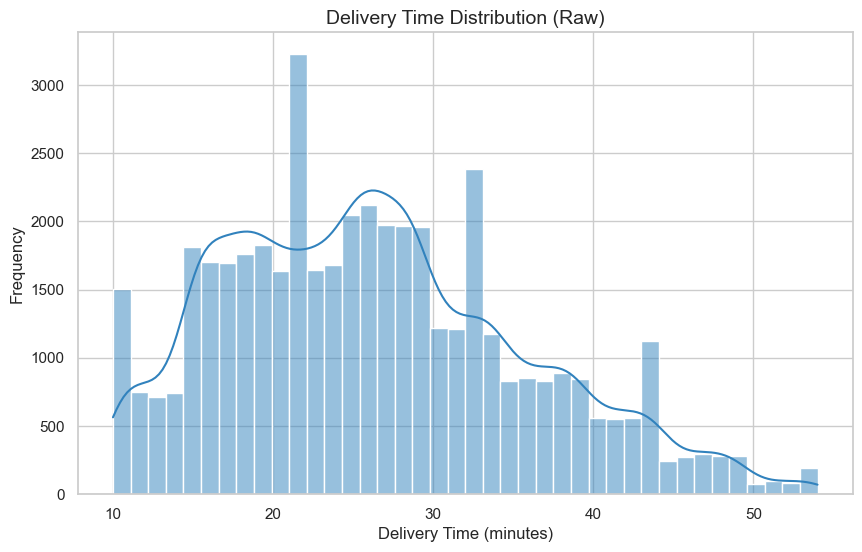

In [50]:
delivery_time_temp = pd.to_numeric(
    df["delivery_time_min"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

plt.figure(figsize=(10, 6))
sns.histplot(delivery_time_temp, bins=40, kde=True)
plt.title("Delivery Time Distribution (Raw)")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
save_plot("delivery_time_distribution_raw")
plt.show()

# Boxplot

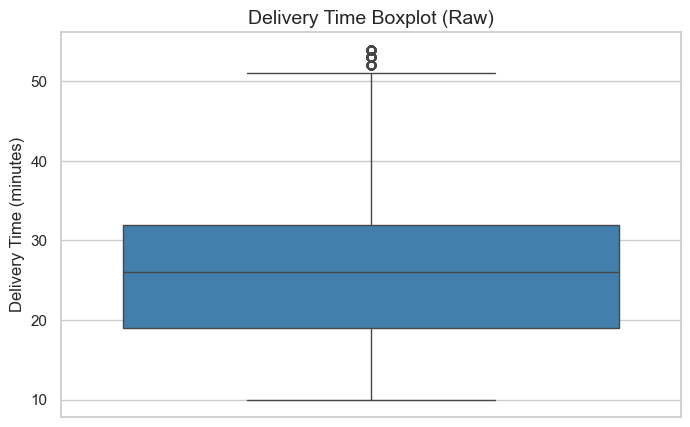

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=delivery_time_temp)
plt.title("Delivery Time Boxplot (Raw)")
plt.ylabel("Delivery Time (minutes)")
save_plot("delivery_time_boxplot_raw")
plt.show()

# Driver Rating

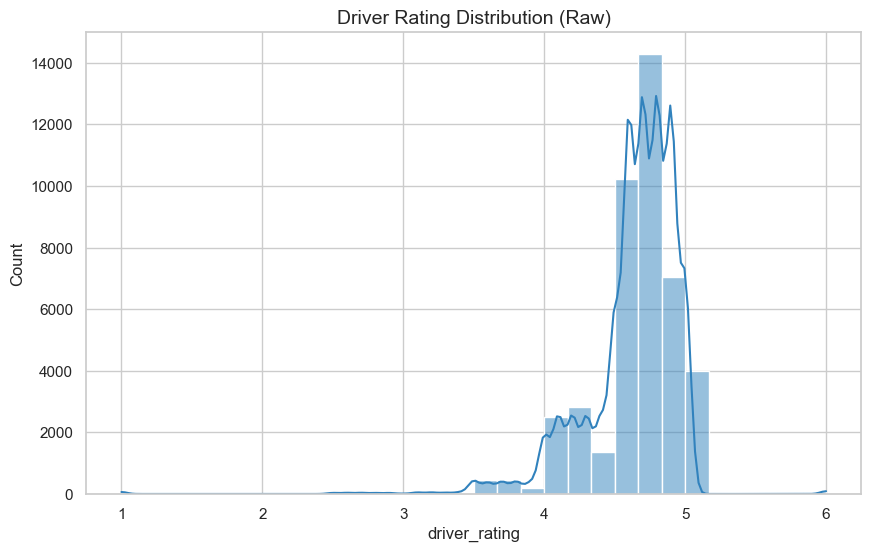

In [52]:
driver_rating_temp = pd.to_numeric(df["driver_rating"], errors="coerce")

plt.figure()
sns.histplot(driver_rating_temp, bins=30, kde=True)
plt.title("Driver Rating Distribution (Raw)")
save_plot("driver_rating_distribution_raw")
plt.show()

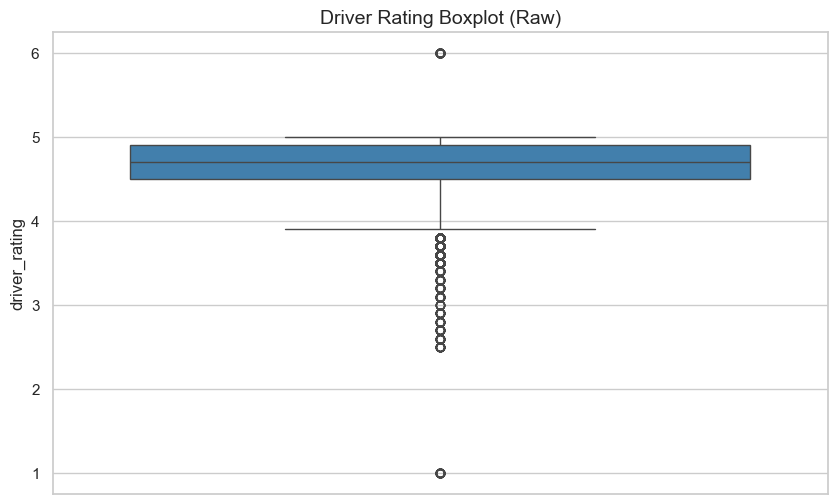

In [53]:
plt.figure()
sns.boxplot(y=driver_rating_temp)
plt.title("Driver Rating Boxplot (Raw)")
save_plot("driver_rating_boxplot_raw")
plt.show()

# Numeric Features

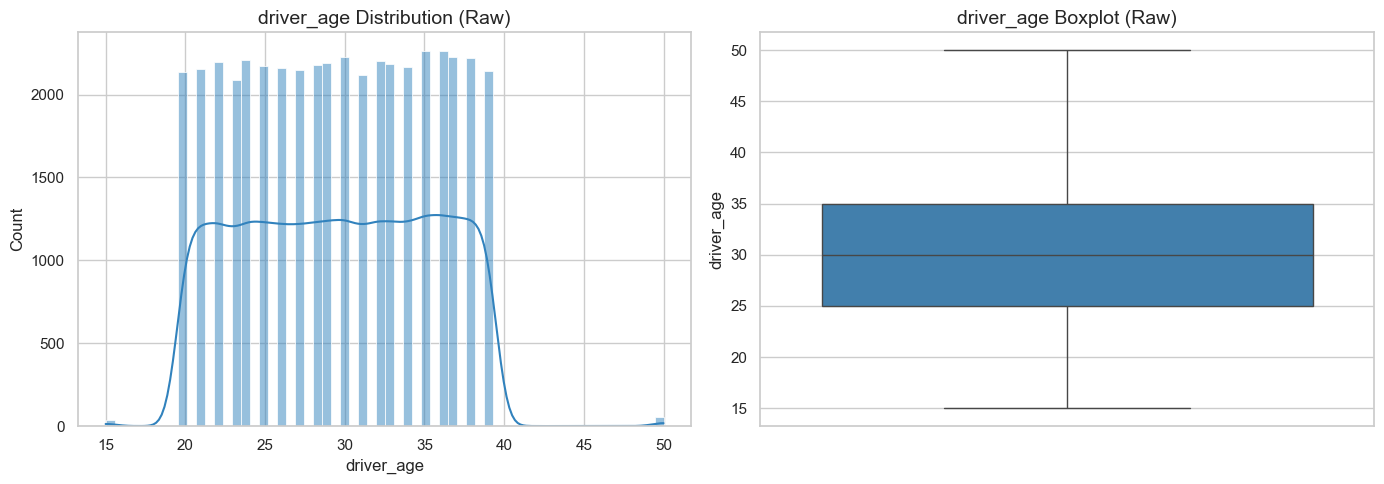

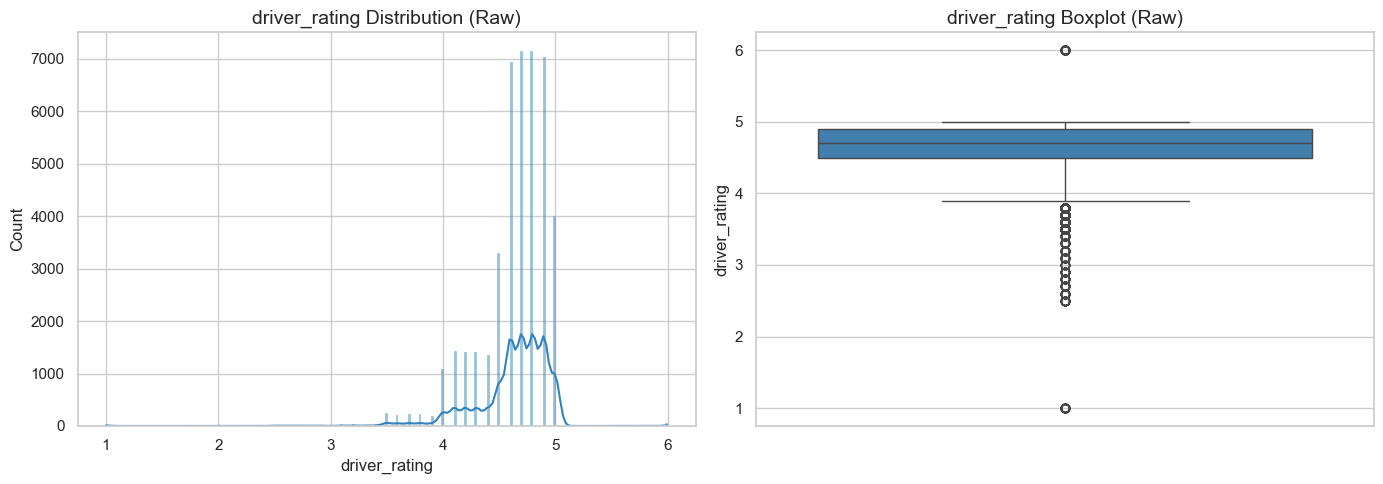

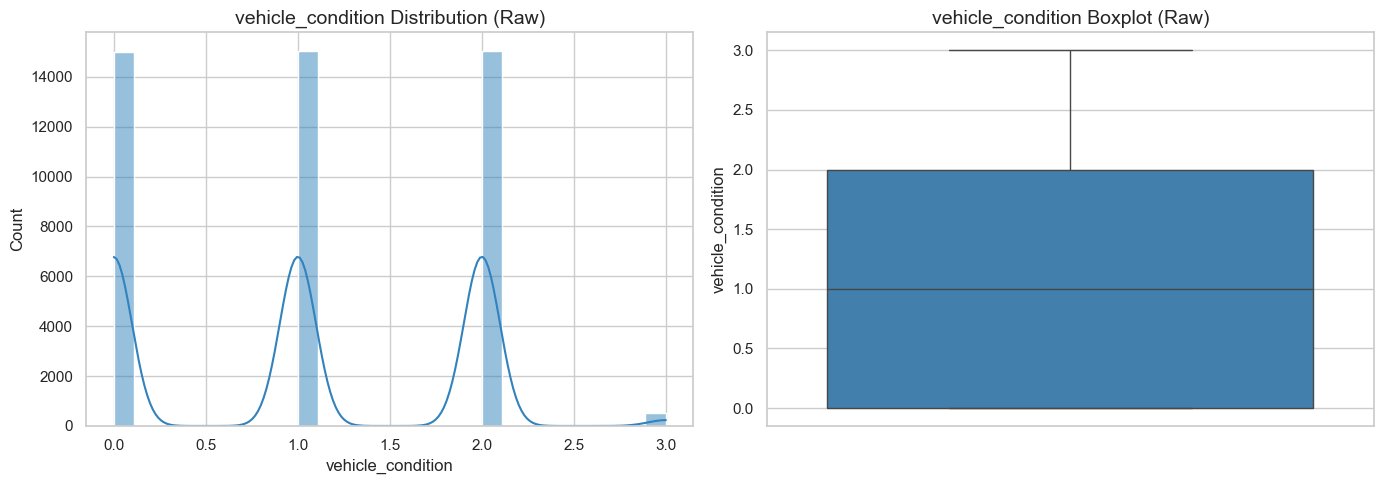

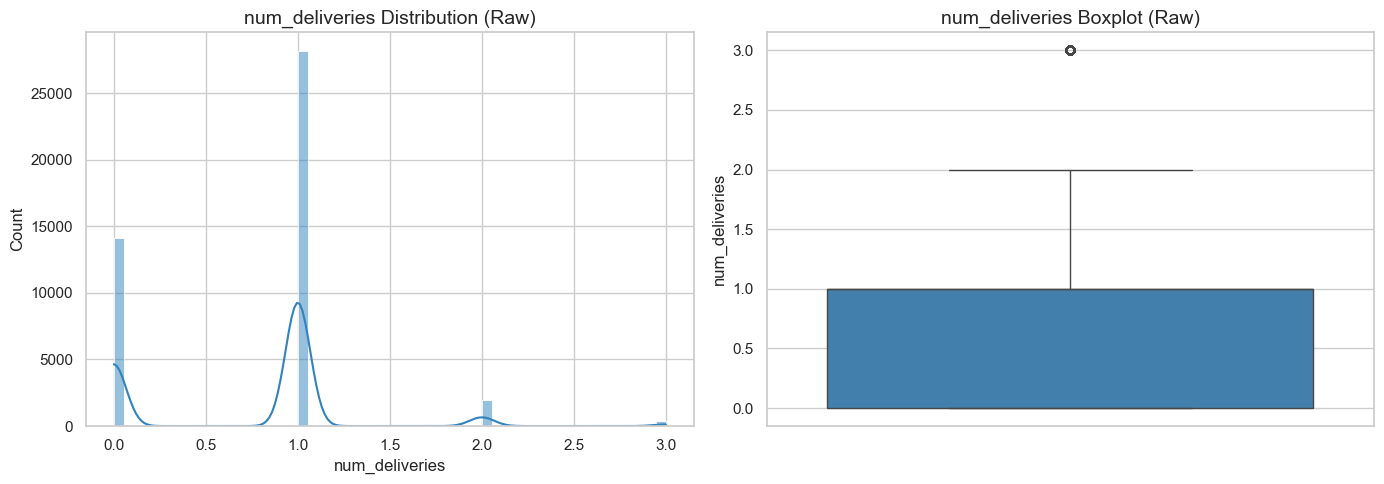

In [54]:
raw_numeric_cols = ["driver_age", "driver_rating", "vehicle_condition", "num_deliveries"]

for col in raw_numeric_cols:
    temp_col = pd.to_numeric(df[col], errors="coerce")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(temp_col, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution (Raw)")

    sns.boxplot(y=temp_col, ax=axes[1])
    axes[1].set_title(f"{col} Boxplot (Raw)")

    plt.tight_layout()
    save_plot(f"{col}_raw_analysis")
    plt.show()

# Categorical Distributions

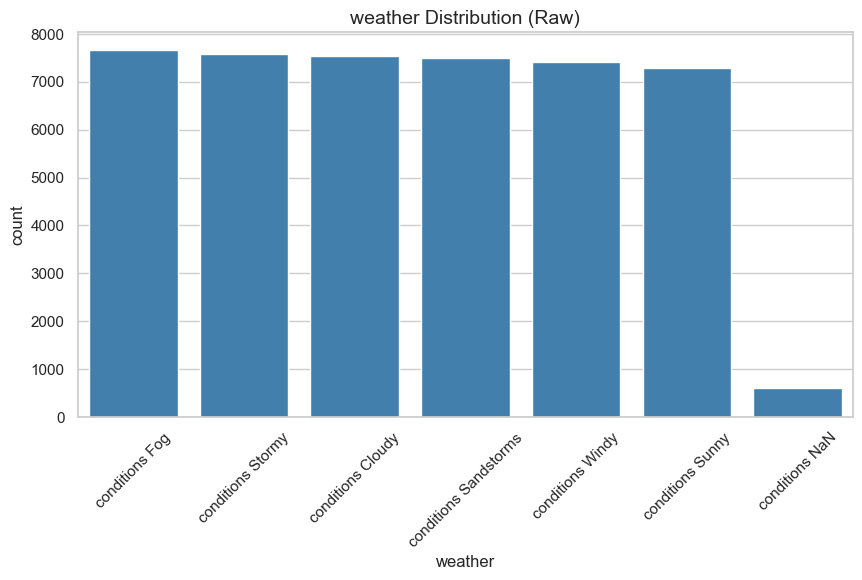

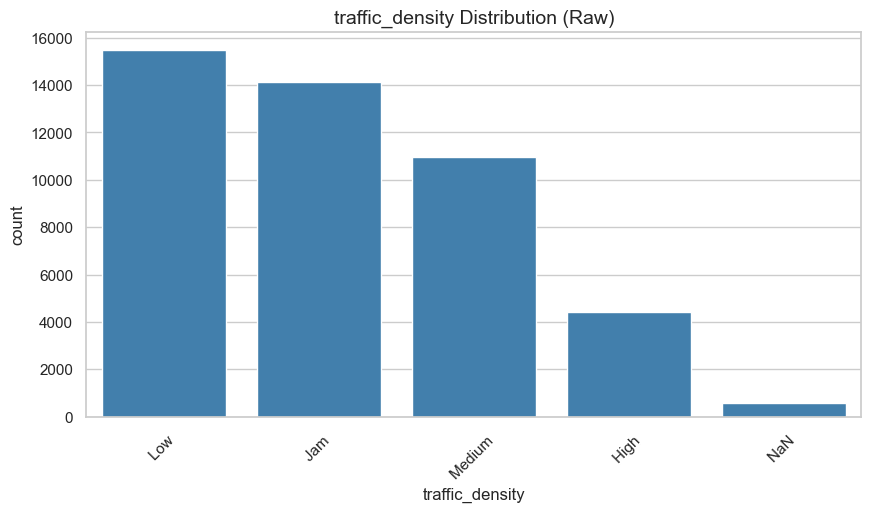

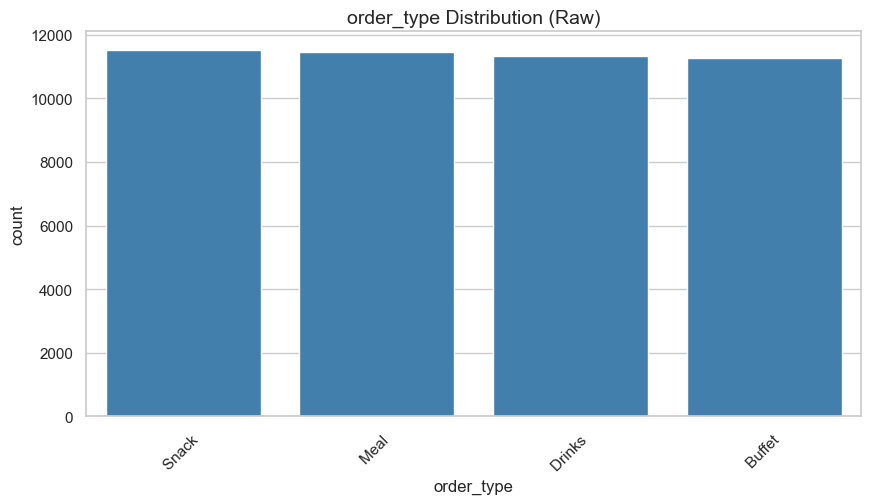

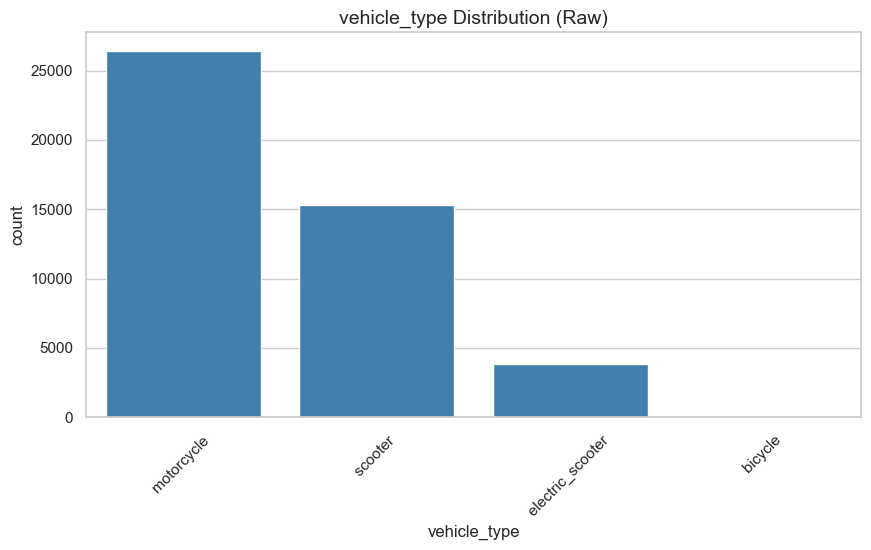

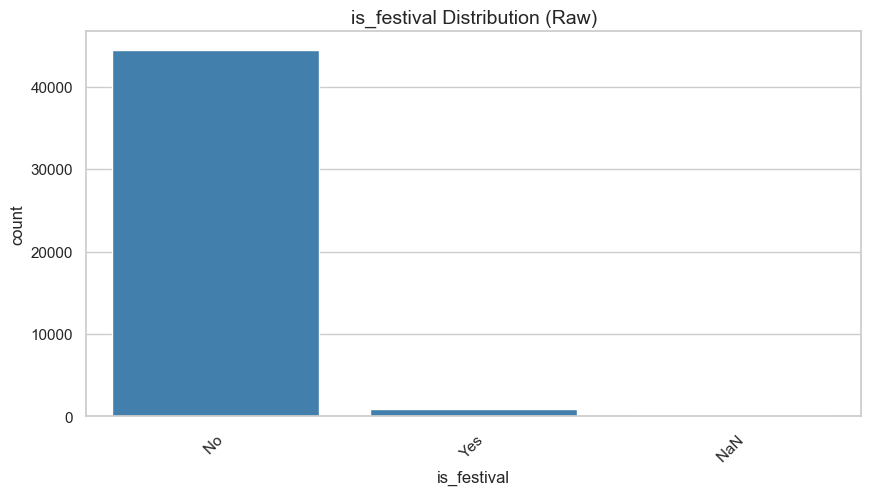

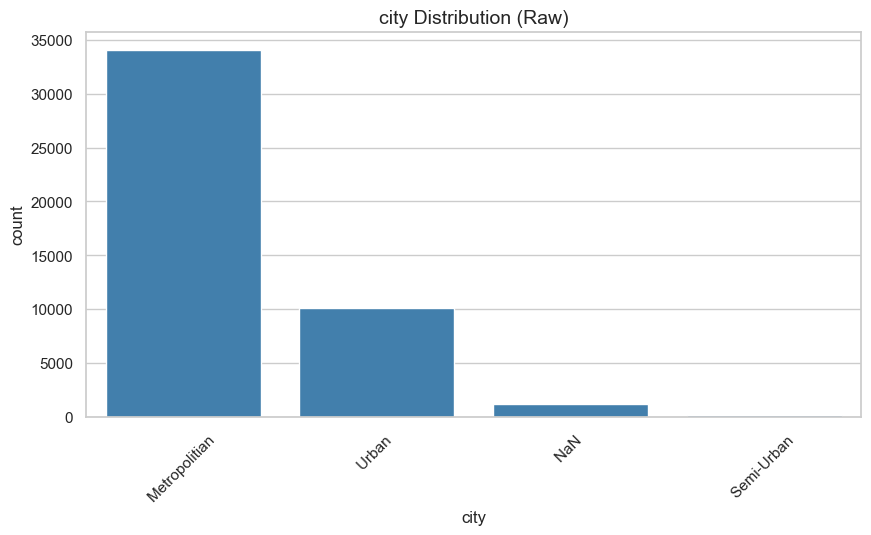

In [55]:
cat_plot_cols = ["weather", "traffic_density", "order_type", "vehicle_type", "is_festival", "city"]

for col in cat_plot_cols:
    plt.figure(figsize=(10, 5))
    order = df[col].astype(str).value_counts(dropna=False).index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"{col} Distribution (Raw)")
    plt.xticks(rotation=45)
    save_plot(f"{col}_distribution_raw")
    plt.show()

# TARGET VS CATEGORICAL

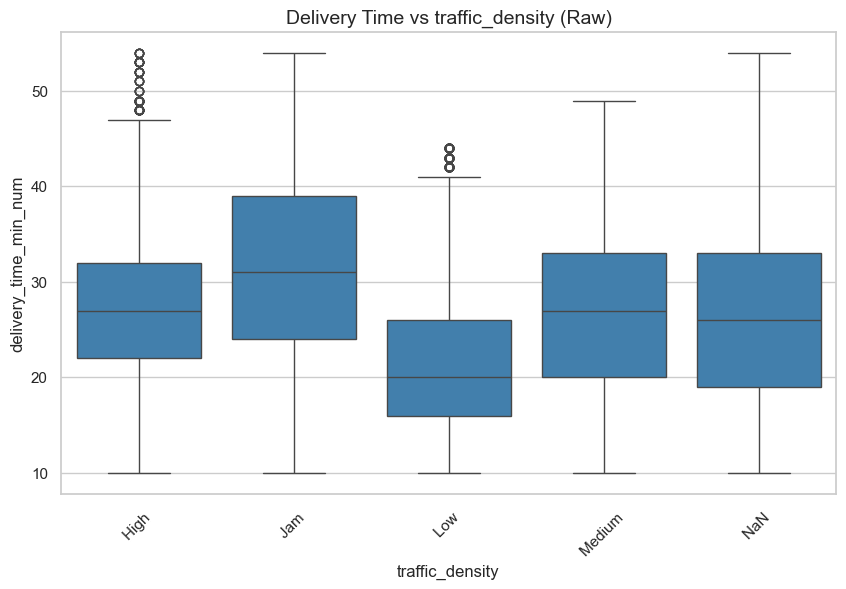

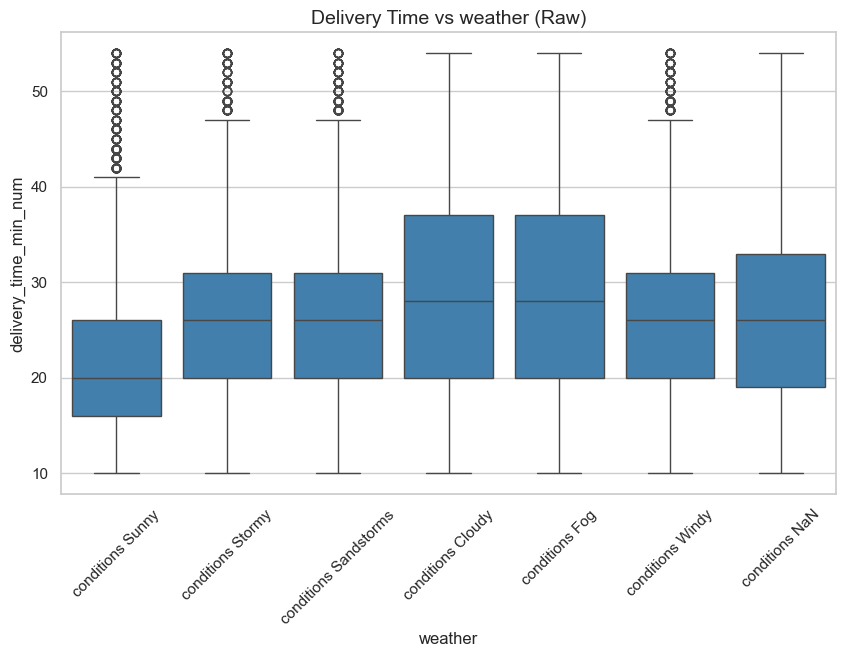

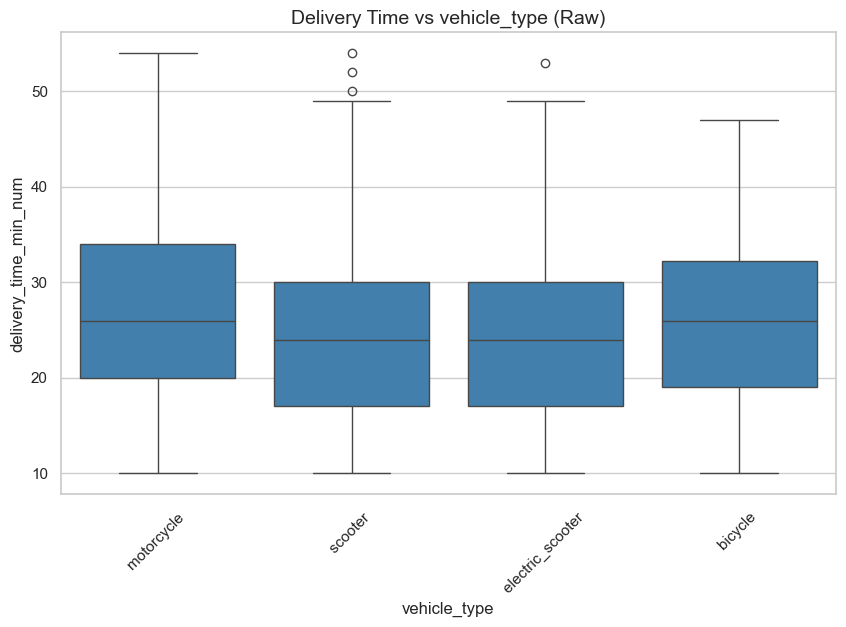

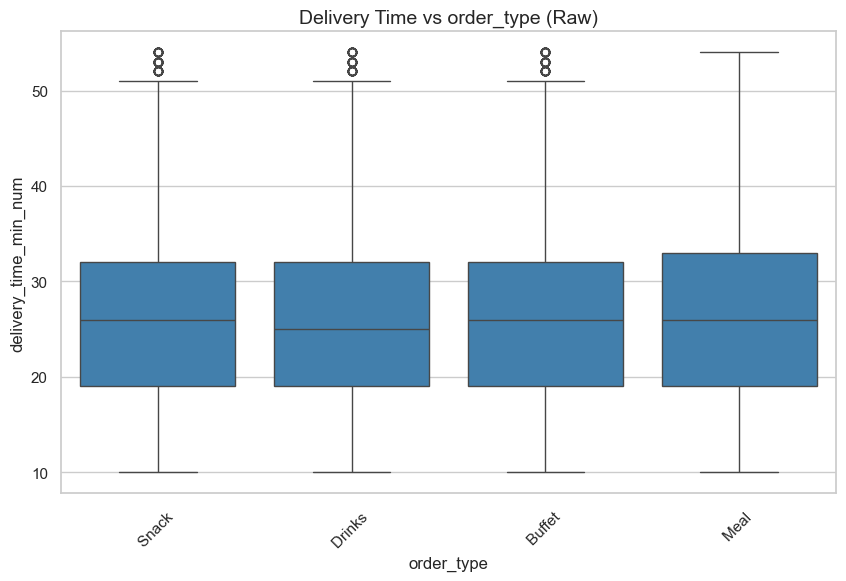

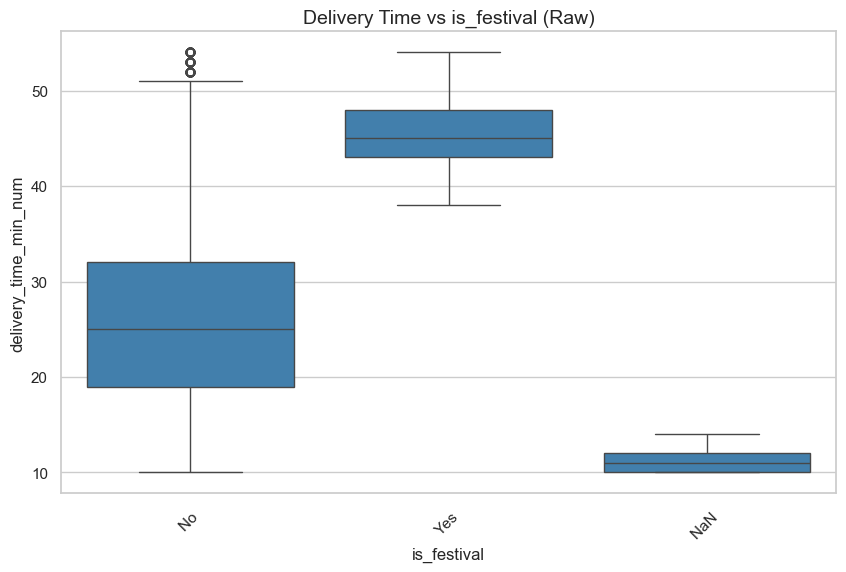

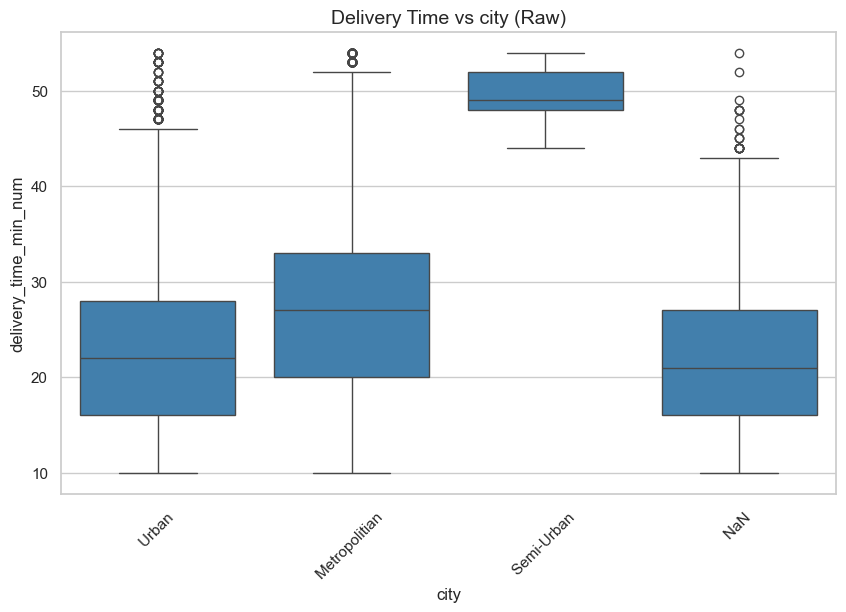

In [56]:
df_plot = df.copy()
df_plot["delivery_time_min_num"] = pd.to_numeric(
    df_plot["delivery_time_min"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

for col in ["traffic_density", "weather", "vehicle_type", "order_type", "is_festival", "city"]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot, x=col, y="delivery_time_min_num")
    plt.title(f"Delivery Time vs {col} (Raw)")
    plt.xticks(rotation=45)
    save_plot(f"delivery_time_vs_{col}_raw")
    plt.show()

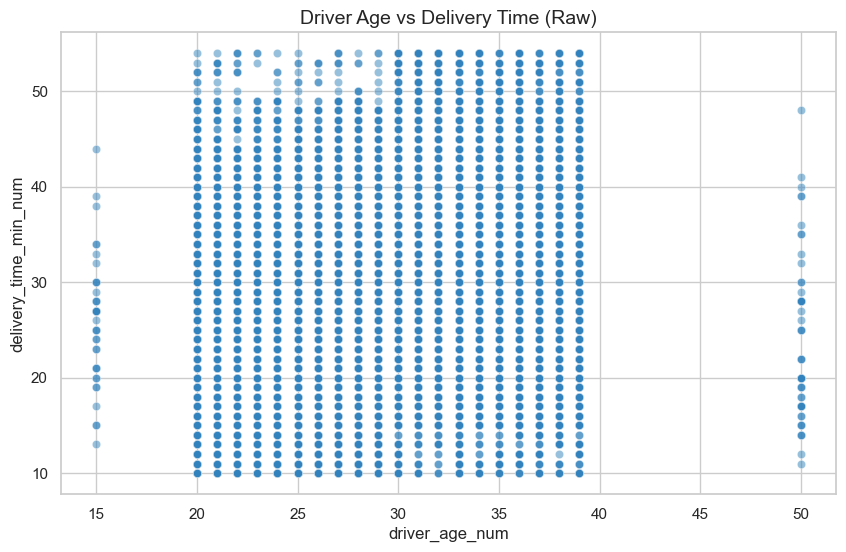

In [58]:
# =========================
# NUMERIC VS TARGET
# =========================
df_plot["driver_age_num"] = pd.to_numeric(df_plot["driver_age"], errors="coerce")
df_plot["driver_rating_num"] = pd.to_numeric(df_plot["driver_rating"], errors="coerce")
df_plot["num_deliveries_num"] = pd.to_numeric(df_plot["num_deliveries"], errors="coerce")
df_plot["vehicle_condition_num"] = pd.to_numeric(df_plot["vehicle_condition"], errors="coerce")

plt.figure()
sns.scatterplot(data=df_plot, x="driver_age_num", y="delivery_time_min_num", alpha=0.5)
plt.title("Driver Age vs Delivery Time (Raw)")
save_plot("driver_age_vs_delivery_time_raw")
plt.show()

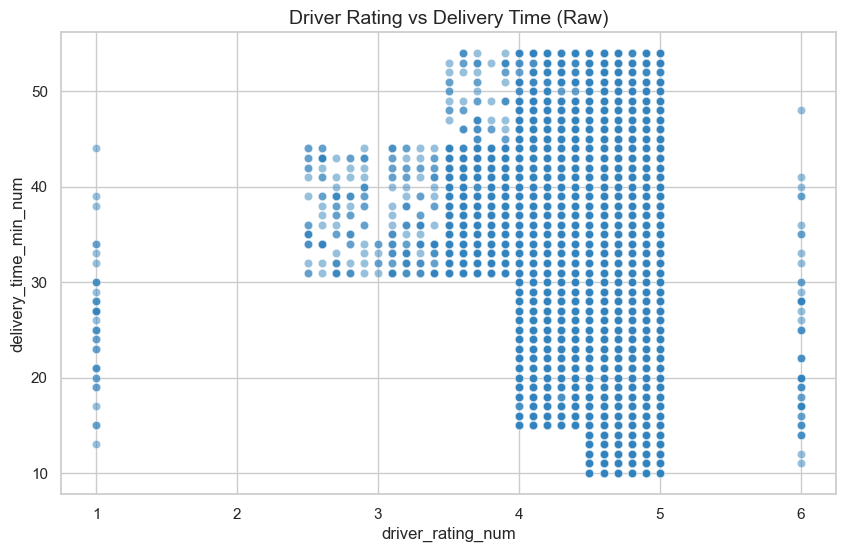

In [59]:

plt.figure()
sns.scatterplot(data=df_plot, x="driver_rating_num", y="delivery_time_min_num", alpha=0.5)
plt.title("Driver Rating vs Delivery Time (Raw)")
save_plot("driver_rating_vs_delivery_time_raw")
plt.show()


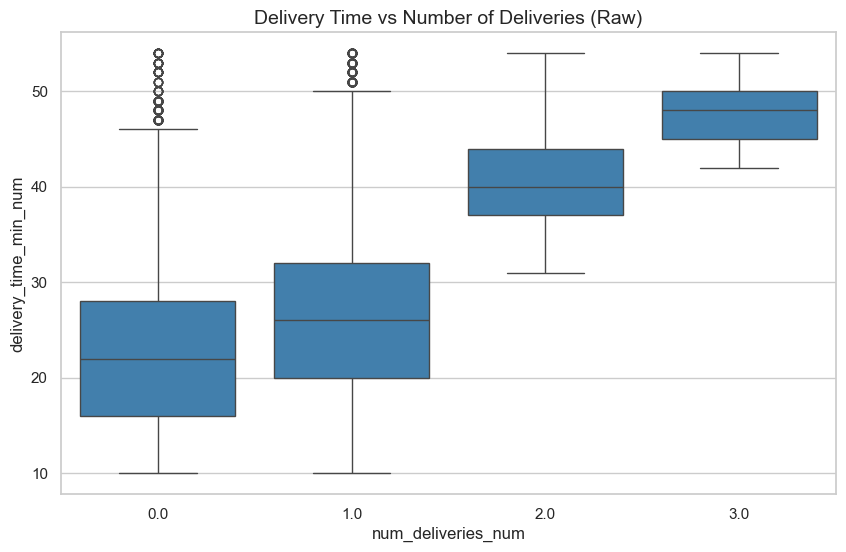

In [60]:

plt.figure()
sns.boxplot(data=df_plot, x="num_deliveries_num", y="delivery_time_min_num")
plt.title("Delivery Time vs Number of Deliveries (Raw)")
save_plot("num_deliveries_vs_delivery_time_raw")
plt.show()



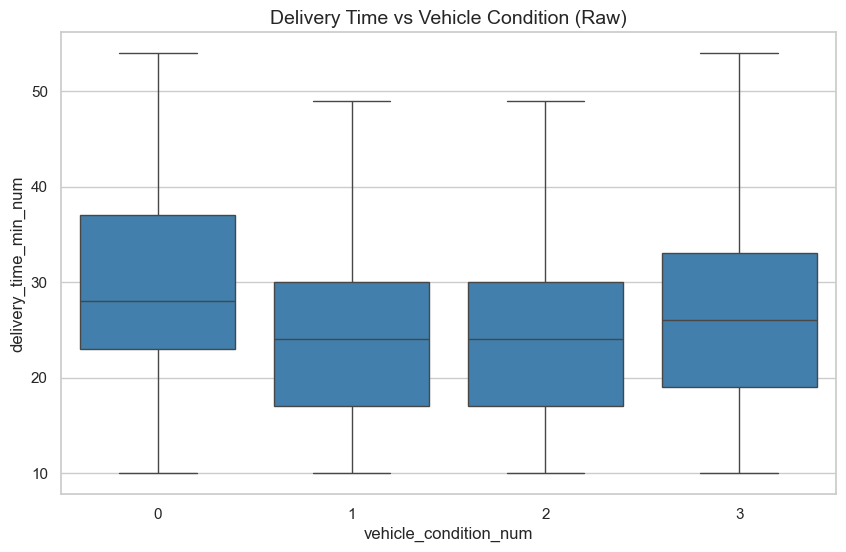

In [61]:
plt.figure()
sns.boxplot(data=df_plot, x="vehicle_condition_num", y="delivery_time_min_num")
plt.title("Delivery Time vs Vehicle Condition (Raw)")
save_plot("vehicle_condition_vs_delivery_time_raw")
plt.show()

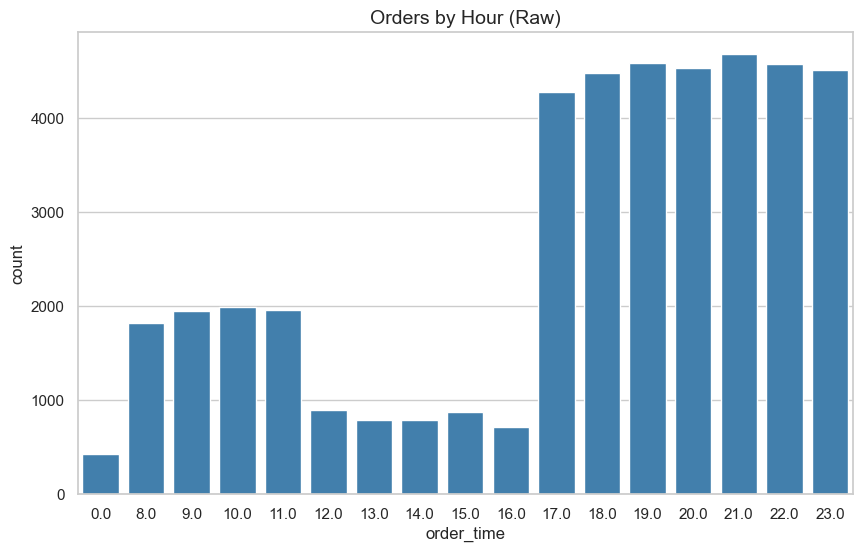

In [62]:
# =========================
# TIME ANALYSIS
# =========================
order_time_temp = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce")
order_hour_temp = order_time_temp.dt.hour

plt.figure()
sns.countplot(x=order_hour_temp)
plt.title("Orders by Hour (Raw)")
save_plot("orders_by_hour_raw")
plt.show()

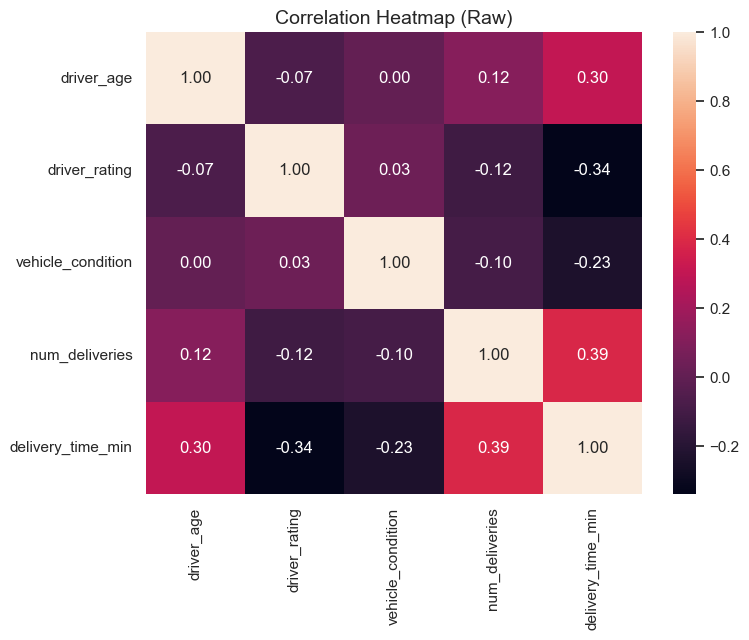

In [95]:
# =========================
# CORRELATION HEATMAP
# =========================
corr_df = pd.DataFrame({
    "driver_age": pd.to_numeric(df["driver_age"], errors="coerce"),
    "driver_rating": pd.to_numeric(df["driver_rating"], errors="coerce"),
    "vehicle_condition": pd.to_numeric(df["vehicle_condition"], errors="coerce"),
    "num_deliveries": pd.to_numeric(df["num_deliveries"], errors="coerce"),
    "delivery_time_min": pd.to_numeric(df["delivery_time_min"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
})

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Raw)")
save_plot("correlation_heatmap_raw")
plt.show()

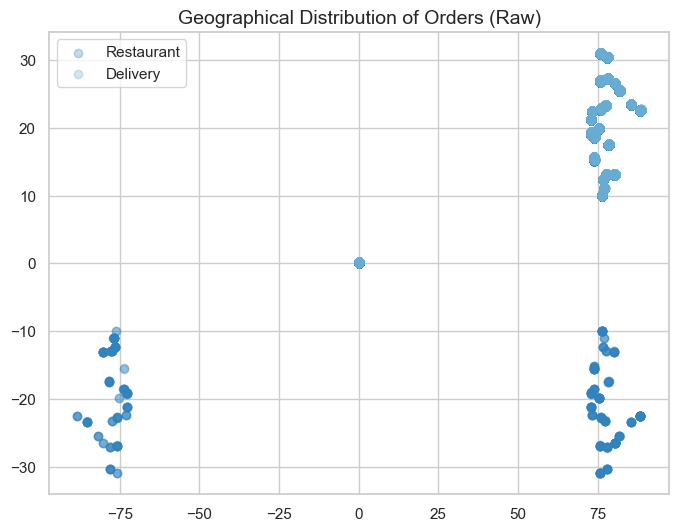

In [97]:
plt.figure(figsize=(8,6))
plt.scatter(df["restaurant_longitude"], df["restaurant_latitude"], alpha=0.3, label="Restaurant")
plt.scatter(df["delivery_longitude"], df["delivery_latitude"], alpha=0.3, label="Delivery")
plt.legend()
plt.title("Geographical Distribution of Orders (Raw)")
save_plot("geo_distribution_raw")
plt.show()

# ADD SUMMARY OF INISHGTS BASED ON WHICH CLEANING WILL BE DONE